In [1]:
import tkinter as tk
from tkinter import filedialog
import sys
import pandas as pd
import numpy as np


ruta = "C:\\Users\\andy0\\Documents\\Tesis\\00_Dataset\\3_IRLANDA\\8_OFICINAS\\satcomm_milltown-office_Customers.csv"
df = pd.read_csv(ruta)
df.head()




,timestamp (5 min),meter_1A,meter_1C,meter_1D,meter_1E,meter_1F,meter_1H,meter_1J,meter_1K,meter_1L
0,2022-01-01 00:00:00,17.46134,9.05703,11.37111,0.32544,2.24366,1.25141,8.76675,9.49346,5.73087
1,2022-01-01 00:05:00,17.45513,9.04988,12.85424,0.30610,2.24337,1.31265,8.75784,9.49057,5.72847
2,2022-01-01 00:10:00,17.41646,9.02028,12.80825,0.30539,2.23196,1.31347,8.73241,9.45984,5.70736
3,2022-01-01 00:15:00,17.53623,9.06873,12.86122,0.30438,2.24449,1.31492,8.77164,9.50723,5.73743
4,2022-01-01 00:20:00,17.54791,9.08220,12.87075,0.21380,2.24841,1.32038,8.78143,9.51675,5.74386


In [2]:
import pandas as pd

def process_meters_to_single_dict(df):
    # 1. Preparar el índice
    df['timestamp (5 min)'] = pd.to_datetime(df['timestamp (5 min)'])
    df = df.set_index('timestamp (5 min)')
    
    # 2. Identificar columnas de medidores
    meter_columns = [col for col in df.columns if col.startswith('meter_')]
    
    # Esta es tu "Variable Única"
    meters_dict = {}

    for meter in meter_columns:
        # Procesamos cada medidor
        temp_df = df[[meter]].copy()
        temp_df[meter] = pd.to_numeric(temp_df[meter], errors='coerce')
        
        # Reindexar a 15 min e interpolar
        rango = pd.date_range(start=temp_df.index.min(), end=temp_df.index.max(), freq="15min")
        temp_df = temp_df.reindex(rango)
        temp_df = temp_df.interpolate(method="linear")
        
        # Guardar dentro de la variable única
        meters_dict[meter] = temp_df

    return meters_dict

base_de_datos = process_meters_to_single_dict(df)
print(base_de_datos['meter_1D'].head())  # Ejemplo de acceso a un medidor específico

                     meter_1D
2022-01-01 00:00:00  11.37111
2022-01-01 00:15:00  12.86122
2022-01-01 00:30:00  12.89404
2022-01-01 00:45:00  11.55282
2022-01-01 01:00:00  11.63432


In [3]:
df = base_de_datos['meter_1A'].copy()
df.columns = ["PLANT CONSUMPTION (KWh)"]
columna_objetivo = 'PLANT CONSUMPTION (KWh)'

df[columna_objetivo] = df[columna_objetivo].apply(lambda x: x if x >= 0 else 0)
# def inject_spike(df, time, factor):
#     df.loc[time, "PLANT CONSUMPTION (KWh)"] *= factor
#     df.loc[time, "anomaly_type"] = "spike"
#     return df

# def inject_drop(df, time, factor):
#     df.loc[time, "PLANT CONSUMPTION (KWh)"] *= factor
#     df.loc[time, "anomaly_type"] = "drop"
#     return df

# def inject_level_shift(df, start, periods, offset):
#     idx = df.index.get_loc(start)
#     for i in range(periods):
#         df.iloc[idx + i, df.columns.get_loc("PLANT CONSUMPTION (KWh)")] += offset
#         df.iloc[idx + i, df.columns.get_loc("anomaly_type")] = "level_shift"
#     return df




# df['anomaly_type'] = 'none'

# # 🔹 SPIKES
# #df = inject_spike(df, pd.Timestamp("2023-05-13 13:00"), factor=4)
# #df = inject_spike(df, pd.Timestamp("2023-05-28 09:00"), factor=4)
# #df = inject_spike(df, pd.Timestamp("2023-06-10 18:00"), factor=4.5)
# #df = inject_spike(df, pd.Timestamp("2023-06-26 3:00"), factor=4.5)
# #df = inject_spike(df, pd.Timestamp("2023-07-07 22:00"), factor=4)

# #test
# df = inject_spike(df, pd.Timestamp("2022-12-13 13:00"), factor=4)
# df = inject_spike(df, pd.Timestamp("2022-11-28 09:00"), factor=4)
# df = inject_spike(df, pd.Timestamp("2022-12-10 18:00"), factor=4.5)
# df = inject_spike(df, pd.Timestamp("2022-11-29 3:00"), factor=4.5)
# df = inject_spike(df, pd.Timestamp("2022-12-07 22:00"), factor=4)

# # 🔹 DROPS
# #df = inject_drop(df, pd.Timestamp("2023-05-05 02:00"), factor=0.1)
# #df = inject_drop(df, pd.Timestamp("2023-06-27 04:00"), factor=0.2)
# #df = inject_drop(df, pd.Timestamp("2023-06-13 03:00"), factor=0.1)
# #df = inject_drop(df, pd.Timestamp("2023-06-11 5:00"), factor=0.2)
# #df = inject_drop(df, pd.Timestamp("2023-05-29 22:00"), factor=0.1)
# #test
# df = inject_drop(df, pd.Timestamp("2022-12-05 02:00"), factor=0.1)
# df = inject_drop(df, pd.Timestamp("2022-12-09 04:00"), factor=0.2)
# df = inject_drop(df, pd.Timestamp("2022-12-15 03:00"), factor=0.1)
# df = inject_drop(df, pd.Timestamp("2022-12-11 3:00"), factor=0.2)
# df = inject_drop(df, pd.Timestamp("2022-11-30 22:00"), factor=0.1)

# # Ejemplo: consumo sube 5 kWh de golpe durante 2 horas
# #df = inject_level_shift(df, pd.Timestamp("2023-06-28 08:00"), periods=3, offset=5.0)
# #df = inject_level_shift(df, pd.Timestamp("2023-07-22 07:00"), periods=3, offset=3.0)
# #df = inject_level_shift(df, pd.Timestamp("2023-06-16 02:00"), periods=3, offset=7.5)
# #test
# df = inject_level_shift(df, pd.Timestamp("2022-12-14 08:00"), periods=3, offset=5.0)
# df = inject_level_shift(df, pd.Timestamp("2022-12-22 07:00"), periods=3, offset=3.0)
# df = inject_level_shift(df, pd.Timestamp("2022-12-16 02:00"), periods=3, offset=7.5)
# # 🔹 DRIFTS
# #df = inject_drift(df, pd.Timestamp("2024-03-26 08:00"), periods=3)
# #df = inject_drift(df, pd.Timestamp("2024-03-07 07:30"), periods=3)
# #df = inject_drift(df, pd.Timestamp("2024-03-16 10:00"), periods=3)
def time_features(df):
    minutos_dia = df.index.hour * 60 
    periodo = 24 * 60
    df["hora_sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["hora_cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    df["dia_semana"] = df.index.dayofweek

    return df

df = time_features(df)
# # 🔹 Etiqueta binaria
# df['is_anomaly'] = (df['anomaly_type'] != 'none').astype(int)
# anomaly=df["anomaly_type"]
# del df["anomaly_type"]
# print(df.shape)

In [4]:
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURACIÓN
# =============================================================================

# Columna donde se modificarán los valores
TARGET_COLUMN = "PLANT CONSUMPTION (KWh)"

# División de los datos:
# 80 % entrenamiento, 10 % validación y 10 % test
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10

# Porcentaje de anomalías que se insertará en el conjunto de test
# 0.0012 equivale al 0.12 %
ANOMALY_PERCENTAGE = 0.0032

# Un spike será 2.5 veces el máximo habitual
SPIKE_FACTOR = 2.5

# Un drop será el 10 % del mínimo habitual
DROP_FACTOR = 0.10

# Semilla para obtener siempre las mismas anomalías
RANDOM_SEED = 42

# Separación mínima entre anomalías
# 4 lecturas de 15 minutos equivalen a una hora
MIN_DISTANCE_READINGS = 100

# Como máximo, el 85 % de los días podrá contener anomalías
ANOMALY_DAY_FRACTION = 0.85

# Número de primeras lecturas del test que se reservan
# para formar la ventana temporal inicial del modelo
RESERVED_READINGS = 96


# =============================================================================
# COMPROBACIONES INICIALES
# =============================================================================

if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError(
        "El índice de df debe ser de tipo DatetimeIndex."
    )

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"No existe la columna '{TARGET_COLUMN}'. "
        f"Columnas disponibles: {df.columns.tolist()}"
    )

# Evitar ejecutar dos veces la inserción de anomalías
if (
    "is_anomaly" in df.columns
    and df["is_anomaly"].eq(1).any()
):
    raise RuntimeError(
        "df ya contiene anomalías. "
        "Vuelve a cargar los datos originales antes de ejecutar esta celda."
    )


# =============================================================================
# ELIMINAR FECHAS DUPLICADAS
# =============================================================================

if df.index.has_duplicates:

    # Contar cuántas filas repetidas existen
    numero_duplicados = df.index.duplicated(
        keep="first"
    ).sum()

    print(
        f"Se encontraron {numero_duplicados} fechas duplicadas."
    )

    # Asegurar que el índice tiene un nombre
    if df.index.name is None:
        df.index.name = "datetime"

    nombre_indice = df.index.name

    # Pasar temporalmente la fecha a una columna
    df.reset_index(inplace=True)

    # Conservar solamente la primera fila de cada fecha
    df.drop_duplicates(
        subset=[nombre_indice],
        keep="first",
        inplace=True
    )

    # Volver a colocar la fecha como índice
    df.set_index(
        nombre_indice,
        inplace=True
    )

    print(
        "Se conservó la primera lectura de cada fecha."
    )


# Ordenar cronológicamente
df.sort_index(inplace=True)

df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)

#
# is_anomaly:
# 0 = dato normal
# 1 = anomalía
#
# anomaly_type:
# none  = dato normal
# spike = anomalía superior
# drop  = anomalía inferior
df["is_anomaly"] = 0
df["anomaly_type"] = "none"


# =============================================================================
# =============================================================================

numero_total_datos = len(df)

numero_train = int(
    TRAIN_SIZE * numero_total_datos
)

numero_validacion = int(
    VAL_SIZE * numero_total_datos
)

inicio_test = numero_train + numero_validacion

test = df.iloc[inicio_test:]

if test.empty:
    raise ValueError(
        "El conjunto de test está vacío."
    )

if len(test) <= RESERVED_READINGS:
    raise ValueError(
        "El conjunto de test no contiene suficientes registros "
        "después de reservar las primeras 96 lecturas."
    )

valid_test = test[
    [TARGET_COLUMN]
].dropna().copy()

if valid_test.empty:
    raise ValueError(
        "El conjunto de test no contiene valores válidos."
    )


# =============================================================================
# CREAR INFORMACIÓN TEMPORAL
# =============================================================================

# lunes = 0, martes = 1, ..., domingo = 6
valid_test["_weekday"] = (
    valid_test.index.dayofweek
)

# Por ejemplo: 00:00, 00:15, 00:30...
valid_test["_reading_time"] = (
    valid_test.index.time
)


# =============================================================================
# =============================================================================

# - día de la semana
# - momento exacto de la lectura
groups = valid_test.groupby(
    ["_weekday", "_reading_time"],
    sort=False
)

group_values = groups[TARGET_COLUMN].agg(
    max_value="max",
    min_value="min"
)

group_values["max_timestamp"] = (
    groups[TARGET_COLUMN].idxmax()
)

group_values["min_timestamp"] = (
    groups[TARGET_COLUMN].idxmin()
)

group_values["group_size"] = (
    groups[TARGET_COLUMN].size()
)

group_values = group_values[
    group_values["group_size"] >= 2
]

if group_values.empty:
    raise ValueError(
        "No existen suficientes lecturas repetidas "
        "por día de la semana y momento de lectura."
    )

valid_test = valid_test.join(
    group_values,
    on=["_weekday", "_reading_time"],
    how="inner"
)


# =============================================================================
# CALCULAR EL NÚMERO DE ANOMALÍAS
# =============================================================================

numero_anomalias = int(
    round(
        len(test) * ANOMALY_PERCENTAGE
    )
)

# Se necesita un número par:
# la mitad serán spikes y la otra mitad drops
if numero_anomalias % 2 != 0:
    numero_anomalias -= 1

if numero_anomalias < 2:
    raise ValueError(
        "El conjunto de test es demasiado pequeño "
        "para insertar anomalías."
    )

numero_spikes = numero_anomalias // 2
numero_drops = numero_anomalias // 2


# =============================================================================
# SELECCIONAR LOS DÍAS CON ANOMALÍAS
# =============================================================================

dias_disponibles = pd.DatetimeIndex(
    valid_test.index.normalize().unique()
)

numero_dias_seleccionados = int(
    np.ceil(
        len(dias_disponibles)
        * ANOMALY_DAY_FRACTION
    )
)

# Dejar al menos un día sin anomalías
numero_dias_seleccionados = min(
    numero_dias_seleccionados,
    len(dias_disponibles) - 1
)

numero_dias_seleccionados = max(
    numero_dias_seleccionados,
    1
)


# =============================================================================
# FECHAS RESERVADAS PARA LA VENTANA TEMPORAL
# =============================================================================

# Los primeros 96 registros del test no podrán recibir anomalías.
#
# IMPORTANTE:
# Estas fechas se eliminan de los candidatos DESPUÉS de realizar
# el shuffle para alterar lo mínimo posible la selección aleatoria
# que se obtenía anteriormente con la misma semilla.
fechas_reservadas = set(
    test.index[:RESERVED_READINGS]
)


# =============================================================================
# SELECCIONAR LAS FECHAS DE LAS ANOMALÍAS
# =============================================================================

# Posición de cada fecha dentro del conjunto de test
posiciones_test = {
    fecha: posicion
    for posicion, fecha in enumerate(test.index)
}

spikes_seleccionados = []
drops_seleccionados = []

seleccion_completada = False


# Se realizan varios intentos para encontrar posiciones válidas
for intento in range(200):

    rng = np.random.default_rng(
        RANDOM_SEED + intento
    )

    # Elegir los días que podrán contener anomalías
    dias_seleccionados = pd.DatetimeIndex(
        rng.choice(
            np.asarray(
                dias_disponibles,
                dtype="datetime64[ns]"
            ),
            size=numero_dias_seleccionados,
            replace=False
        )
    )

    # Seleccionar las lecturas de los días elegidos
    candidatos = valid_test[
        valid_test.index.normalize().isin(
            dias_seleccionados
        )
    ]

    # Un spike no se coloca donde ya estaba el máximo
    candidatos_spike = candidatos[
        candidatos.index
        != candidatos["max_timestamp"]
    ].index.to_list()

    # Un drop no se coloca donde ya estaba el mínimo
    candidatos_drop = candidatos[
        candidatos.index
        != candidatos["min_timestamp"]
    ].index.to_list()

    # -------------------------------------------------------------------------
    # IMPORTANTE:
    # Primero se mezclan todos los candidatos con la misma semilla.
    # Después se eliminan las primeras 96 lecturas reservadas.
    #
    # De esta forma, reservar esas lecturas modifica lo mínimo posible
    # las posiciones aleatorias seleccionadas anteriormente.
    # -------------------------------------------------------------------------

    rng.shuffle(candidatos_spike)
    rng.shuffle(candidatos_drop)

    # Eliminar después del shuffle las fechas reservadas
    candidatos_spike = [
        fecha
        for fecha in candidatos_spike
        if fecha not in fechas_reservadas
    ]

    candidatos_drop = [
        fecha
        for fecha in candidatos_drop
        if fecha not in fechas_reservadas
    ]

    spikes_seleccionados = []
    drops_seleccionados = []

    posiciones_seleccionadas = set()
    posiciones_por_dia = {}

    puntero_spike = 0
    puntero_drop = 0


    def posicion_valida(fecha):
        """
        Comprueba que la fecha no esté seleccionada
        y que esté suficientemente separada de otras anomalías.
        """

        posicion = posiciones_test[fecha]
        dia = fecha.normalize()

        # No seleccionar dos veces la misma posición
        if posicion in posiciones_seleccionadas:
            return False

        # No permitir anomalías dentro de las primeras
        # 96 lecturas reservadas
        if fecha in fechas_reservadas:
            return False

        # Comprobar la separación respecto a otras anomalías
        # insertadas en el mismo día
        for posicion_anterior in posiciones_por_dia.get(
            dia,
            []
        ):
            if (
                abs(posicion - posicion_anterior)
                < MIN_DISTANCE_READINGS
            ):
                return False

        return True


    def guardar_posicion(fecha):
        """
        Guarda la posición de una anomalía seleccionada.
        """

        posicion = posiciones_test[fecha]
        dia = fecha.normalize()

        posiciones_seleccionadas.add(
            posicion
        )

        posiciones_por_dia.setdefault(
            dia,
            []
        ).append(
            posicion
        )


    # Alternar la selección de spikes y drops
    while (
        len(spikes_seleccionados) < numero_spikes
        or len(drops_seleccionados) < numero_drops
    ):

        hubo_progreso = False

        # ---------------------------------------------------------------------
        # Seleccionar un spike
        # ---------------------------------------------------------------------

        if len(spikes_seleccionados) < numero_spikes:

            while puntero_spike < len(candidatos_spike):

                fecha = candidatos_spike[
                    puntero_spike
                ]

                puntero_spike += 1

                if posicion_valida(fecha):

                    spikes_seleccionados.append(
                        fecha
                    )

                    guardar_posicion(
                        fecha
                    )

                    hubo_progreso = True

                    break


        # ---------------------------------------------------------------------
        # Seleccionar un drop
        # ---------------------------------------------------------------------

        if len(drops_seleccionados) < numero_drops:

            while puntero_drop < len(candidatos_drop):

                fecha = candidatos_drop[
                    puntero_drop
                ]

                puntero_drop += 1

                if posicion_valida(fecha):

                    drops_seleccionados.append(
                        fecha
                    )

                    guardar_posicion(
                        fecha
                    )

                    hubo_progreso = True

                    break


        # Salir si ya no se encuentran posiciones válidas
        if not hubo_progreso:
            break


    # Comprobar si se encontraron todas las anomalías
    if (
        len(spikes_seleccionados) == numero_spikes
        and len(drops_seleccionados) == numero_drops
    ):
        seleccion_completada = True
        break


if not seleccion_completada:
    raise ValueError(
        "No fue posible insertar todas las anomalías "
        "respetando las restricciones establecidas."
    )


# =============================================================================
# INSERTAR LOS SPIKES
# =============================================================================

for fecha in spikes_seleccionados:

    # Obtener el máximo habitual para ese día de la semana
    # y momento exacto de lectura
    maximo_habitual = valid_test.at[
        fecha,
        "max_value"
    ]

    # Crear el valor anómalo
    valor_spike = (
        maximo_habitual
        * SPIKE_FACTOR
    )

    # Sustituir el consumo original por el valor anómalo
    df.at[
        fecha,
        TARGET_COLUMN
    ] = valor_spike

    # Marcar esa fecha como anomalía
    df.at[
        fecha,
        "is_anomaly"
    ] = 1

    # Guardar el tipo de anomalía
    df.at[
        fecha,
        "anomaly_type"
    ] = "spike"


# =============================================================================
# INSERTAR LOS DROPS
# =============================================================================

for fecha in drops_seleccionados:

    # Obtener el mínimo habitual para ese día de la semana
    # y momento exacto de lectura
    minimo_habitual = valid_test.at[
        fecha,
        "min_value"
    ]

    # Crear el valor anómalo
    valor_drop = (
        minimo_habitual
        * DROP_FACTOR
    )

    # Sustituir el consumo original por el valor anómalo
    df.at[
        fecha,
        TARGET_COLUMN
    ] = valor_drop

    # Marcar esa fecha como anomalía
    df.at[
        fecha,
        "is_anomaly"
    ] = 1

    # Guardar el tipo de anomalía
    df.at[
        fecha,
        "anomaly_type"
    ] = "drop"


# =============================================================================
# =============================================================================

# para poder utilizarlos posteriormente
anomaly = df[
    "anomaly_type"
].copy()


# =============================================================================
# MOSTRAR EL RESULTADO
# =============================================================================

fechas_anomalas = (
    spikes_seleccionados
    + drops_seleccionados
)

dias_con_anomalias = pd.DatetimeIndex(
    fechas_anomalas
).normalize().unique()


print("Proceso terminado correctamente.")
print()

print(
    f"Registros totales: "
    f"{len(df)}"
)

print(
    f"Registros del test: "
    f"{len(test)}"
)

print(
    f"Primeros registros reservados: "
    f"{RESERVED_READINGS}"
)

print(
    f"Anomalías insertadas: "
    f"{numero_anomalias}"
)

print(
    f"Spikes insertados: "
    f"{len(spikes_seleccionados)}"
)

print(
    f"Drops insertados: "
    f"{len(drops_seleccionados)}"
)

print(
    f"Porcentaje de anomalías en el test: "
    f"{numero_anomalias / len(test) * 100:.2f} %"
)

print(
    f"Días con anomalías: "
    f"{len(dias_con_anomalias)} de "
    f"{len(dias_disponibles)}"
)


# =============================================================================
# =============================================================================

anomalias_primeras_96 = df.loc[
    test.index[:RESERVED_READINGS],
    "is_anomaly"
].sum()

print()

print(
    f"Anomalías en las primeras "
    f"{RESERVED_READINGS} lecturas: "
    f"{anomalias_primeras_96}"
)


# =============================================================================
# MOSTRAR LAS PRIMERAS ANOMALÍAS INSERTADAS
# =============================================================================

print()
print(
    "Primeras anomalías insertadas:"
)

print(
    df.loc[
        df["is_anomaly"] == 1,
        [
            TARGET_COLUMN,
            "is_anomaly",
            "anomaly_type"
        ]
    ].head(10)
)


# =============================================================================
# ELIMINAR LA COLUMNA DE TEXTO ANTES DEL ESCALADO
# =============================================================================

# La información de spike, drop y none permanece guardada
# en la variable anomaly.
#
# Se elimina anomaly_type de df porque las siguientes celdas
# realizan escalado numérico y StandardScaler no acepta texto.
df.drop(
    columns=["anomaly_type"],
    inplace=True
)

Proceso terminado correctamente.

Registros totales: 35040
Registros del test: 3504
Primeros registros reservados: 96
Anomalías insertadas: 10
Spikes insertados: 5
Drops insertados: 5
Porcentaje de anomalías en el test: 0.29 %
Días con anomalías: 10 de 37

Anomalías en las primeras 96 lecturas: 0

Primeras anomalías insertadas:
                     PLANT CONSUMPTION (KWh)  is_anomaly anomaly_type
2022-11-29 17:45:00                 0.006827           1         drop
2022-12-03 04:30:00                 0.010814           1         drop
2022-12-04 03:00:00                17.787125           1        spike
2022-12-06 10:45:00                 1.838725           1        spike
2022-12-07 16:00:00                 0.010329           1         drop
2022-12-18 02:45:00                21.594675           1        spike
2022-12-20 17:15:00                 0.010530           1         drop
2022-12-24 07:15:00                 0.010666           1         drop
2022-12-26 19:00:00                 0.40

In [5]:
def stadistical_features(df):
    df["mean_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling("1h").mean().shift(1)
    df["mean_6h"] = df["PLANT CONSUMPTION (KWh)"].rolling("6h").mean().shift(1)
    df["mean_12h"] = df["PLANT CONSUMPTION (KWh)"].rolling("12h").mean().shift(1)
    df["mean_24h"] = df["PLANT CONSUMPTION (KWh)"].rolling("24h").mean().shift(1)
    df['is_on'] = (df['PLANT CONSUMPTION (KWh)'].shift(1) > 5).astype(int)
    df["std_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling(4).std().shift(1)
    df["dy_1"] = df["PLANT CONSUMPTION (KWh)"].diff().shift(1)
    df['dy_2'] = df['PLANT CONSUMPTION (KWh)'].diff(2).shift(1)
    df["v_672"] = df["PLANT CONSUMPTION (KWh)"].shift(24*7).fillna(df["PLANT CONSUMPTION (KWh)"])
    df = df.dropna().copy()
    return df

df_stat = stadistical_features(df)
df_stat.head()

,PLANT CONSUMPTION (KWh),hora_sin,hora_cos,dia_semana,is_anomaly,mean_1h,mean_6h,mean_12h,mean_24h,is_on,std_1h,dy_1,dy_2,v_672
2022-01-01 01:00:00,18.06954,0.258819,0.965926,5,0,17.649505,17.649505,17.649505,17.649505,1,0.187661,0.15479,0.34139,18.06954
2022-01-01 01:15:00,18.01270,0.258819,0.965926,5,0,17.801555,17.733512,17.733512,17.733512,1,0.226713,0.19192,0.34671,18.01270
2022-01-01 01:30:00,18.13603,0.258819,0.965926,5,0,17.920673,17.780043,17.780043,17.780043,1,0.154516,-0.05684,0.13508,18.13603
2022-01-01 01:45:00,18.58616,0.258819,0.965926,5,0,18.023972,17.830899,17.830899,17.830899,1,0.109817,0.12333,0.06649,18.58616
2022-01-01 02:00:00,16.00325,0.500000,0.866025,5,0,18.201108,17.925306,17.925306,17.925306,1,0.261603,0.45013,0.57346,16.00325


In [6]:
def divide_data(df, train_size=0.8, val_size=0.2):
    N = df.shape[0]
    Ntrain = int(train_size * N)  #Número de datos de entrenamiento
    Nval = int(val_size * N)      #Número de datos de validación
    train = df[0:Ntrain]
    val = df[Ntrain : Ntrain + Nval]
    test = df[Ntrain + Nval :]
    return train, val, test

train,val,test = divide_data(df_stat,train_size=0.8, val_size=0.1)
print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (28028, 14)
Tamaño set de validación: (3503, 14)
Tamaño set de prueba: (3505, 14)


In [7]:
from sklearn.preprocessing import StandardScaler

def scale_data(train, val, test, target_col):
    scaler = StandardScaler()
    scaler.fit(train[[target_col]])
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled, scaler


cyclic_cols = ["hora_sin", "hora_cos", "dia_semana", "is_on","is_anomaly"]
train_cyclic = train[cyclic_cols].values
val_cyclic = val[cyclic_cols].values
test_cyclic = test[cyclic_cols].values

tr_scaled, val_scaled, test_scaled, scaler = scale_data(train.drop(columns=cyclic_cols), val.drop(columns=cyclic_cols), test.drop(columns=cyclic_cols), "PLANT CONSUMPTION (KWh)")
X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
X_val_scaled = np.concatenate([val_scaled, val_cyclic], axis=1)
X_test_scaled = np.concatenate([test_scaled, test_cyclic], axis=1)

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
def window(array, input_length, output_length):
    # Inicialización
    X, Y = [], []
    fils, cols = array.shape 
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+input_length,0:1])
        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

X_train_temporal, y_tr= window(X_train_scaled , input_length=96, output_length=1)  
X_val_temporal, y_vl= window(X_val_scaled , input_length=96, output_length=1)
X_test_temporal, y_ts= window(X_test_scaled , input_length=96, output_length=1)

In [9]:
X_train_stat = X_train_scaled[95:-2, 1:-1]
X_val_stat   = X_val_scaled[95:-2, 1:-1]
X_test_stat  = X_test_scaled[95:-2, 1:-1]

In [10]:
y_ts1=y_ts.copy()
X_test_temporal1 = X_test_temporal.copy()
X_test_stat1 = X_test_stat.copy() 

In [11]:
from tensorflow import keras
from keras.models import Sequential,Model
from keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed, Input, Concatenate, Conv1D, MaxPooling1D, Flatten, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

def BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_train, X_val_temporal, X_val_stat, y_val):
    act_func = 'tanh'
    n_feature      = int(X_train_temporal.shape[2])
    n_time_steps   = int(X_train_temporal.shape[1])
    n_feature_stat = int(X_train_stat.shape[1])

    # --- Rama BiLSTM ---
    input_temporal = Input(shape=(n_time_steps, n_feature))
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=True))(input_temporal)
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=False))(x)
    input_stat = Input(shape=(n_feature_stat,))
    y = Dense(64, activation='relu')(input_stat)
    y = Dense(32, activation='relu')(y)
    combined = Concatenate()([x, y])
    output = Dense(1, activation='linear')(combined)
    model = Model(inputs=[input_temporal, input_stat], outputs=output)
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        [X_train_temporal, X_train_stat],
        y_train,
        validation_data=(
            [X_val_temporal, X_val_stat],
            y_val
        ),
        epochs=50,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=10, restore_best_weights=True)
        ]
    )
    return model,history

model_BiLSTM, history = BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_tr, X_val_temporal, X_val_stat, y_vl)

Epoch 1/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - loss: 0.0867 - val_loss: 0.0411
Epoch 2/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - loss: 0.0665 - val_loss: 0.0403
Epoch 3/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - loss: 0.0638 - val_loss: 0.0411
Epoch 4/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 96s 110ms/step - loss: 0.0607 - val_loss: 0.0391
Epoch 5/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 98s 112ms/step - loss: 0.0588 - val_loss: 0.0399
Epoch 6/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 103s 118ms/step - loss: 0.0582 - val_loss: 0.0384
Epoch 7/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 100s 114ms/step - loss: 0.0566 - val_loss: 0.0378
Epoch 8/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 98s 112ms/step - loss: 0.0558 - val_loss: 0.0387
Epoch 9/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 103s 118ms/step - loss: 0.0551 - val_loss: 0.0379
Epoch 10/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 100s 114ms/step - loss: 0.0545 - val_loss: 0.0377
Epoch 11/50
873/873 ━━━━━━━━━━━━━━━━━━━━ 101s 116ms/step - loss: 0.0539 - val_loss: 0.0389
Epoch 12/50
873/8

In [12]:
#from tensorflow.keras.models import load_model

#model_BiLSTM = load_model("model_BiLSTM_officeD.keras")

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))

y_pred_val_scaled = model_BiLSTM.predict([X_val_temporal, X_val_stat])
y_pred_val = scaler.inverse_transform(y_pred_val_scaled)
y_val = scaler.inverse_transform(y_vl.reshape(-1, 1))

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()

eval_reg(y_test_real, y_pred, 'TEST')
eval_reg(y_val, y_pred_val, 'VALIDATION')

107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step
TEST:
  MSE:   1.431
  RMSE:  1.196
  MAE:   0.502
  MAPE:  177.30%
  SMAPE: 60.37%
  R²:    0.8435

VALIDATION:
  MSE:   0.636
  RMSE:  0.798
  MAE:   0.474
  MAPE:  139.82%
  SMAPE: 58.34%
  R²:    0.7865



In [14]:
import numpy as np

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()

eval_reg(y_val[1:], y_val[:-1], 'TEST')

TEST:
  MSE:   1.131
  RMSE:  1.063
  MAE:   0.447
  MAPE:  110.77%
  SMAPE: 34.98%
  R²:    0.6204



107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step


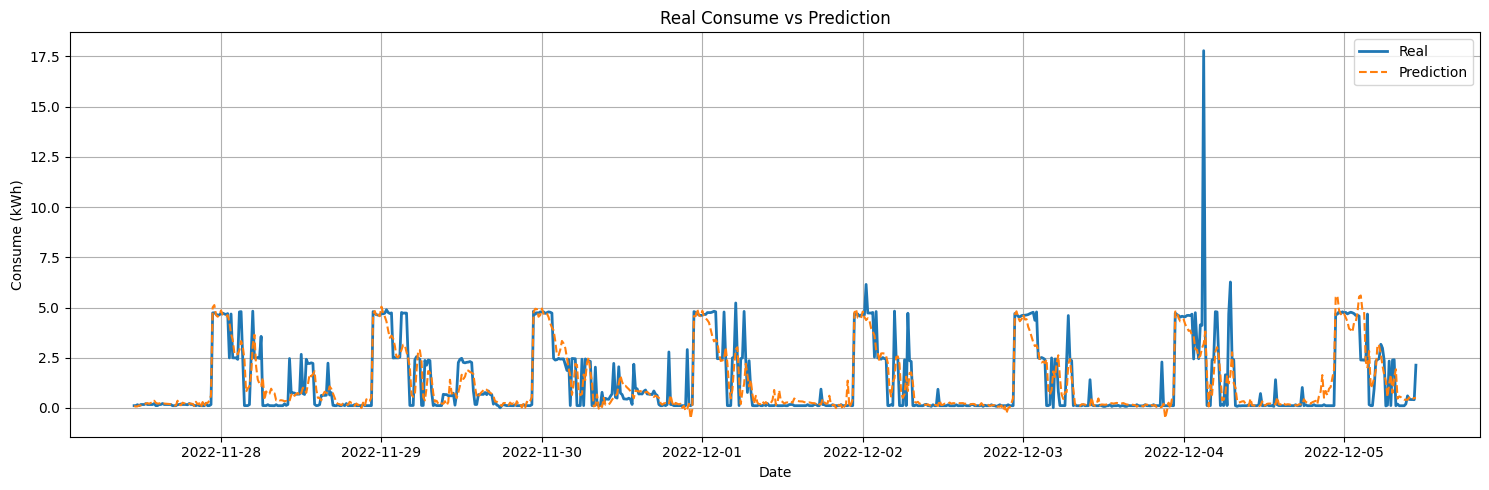

In [15]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=4, idx=1780):
    PTS_DIA = 96*2
    N = n_dias * PTS_DIA
    end = start + N
    x =50
    plt.figure(figsize=(15, 5))
    #plt.plot(ts.index[x:-97], y_real[x:], label='Real', linewidth=2)
    #plt.plot(ts.index[x:-97], y_pred[x:], label='Prediction', linestyle='--')
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=-1, n_dias=4, idx=1780)

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step


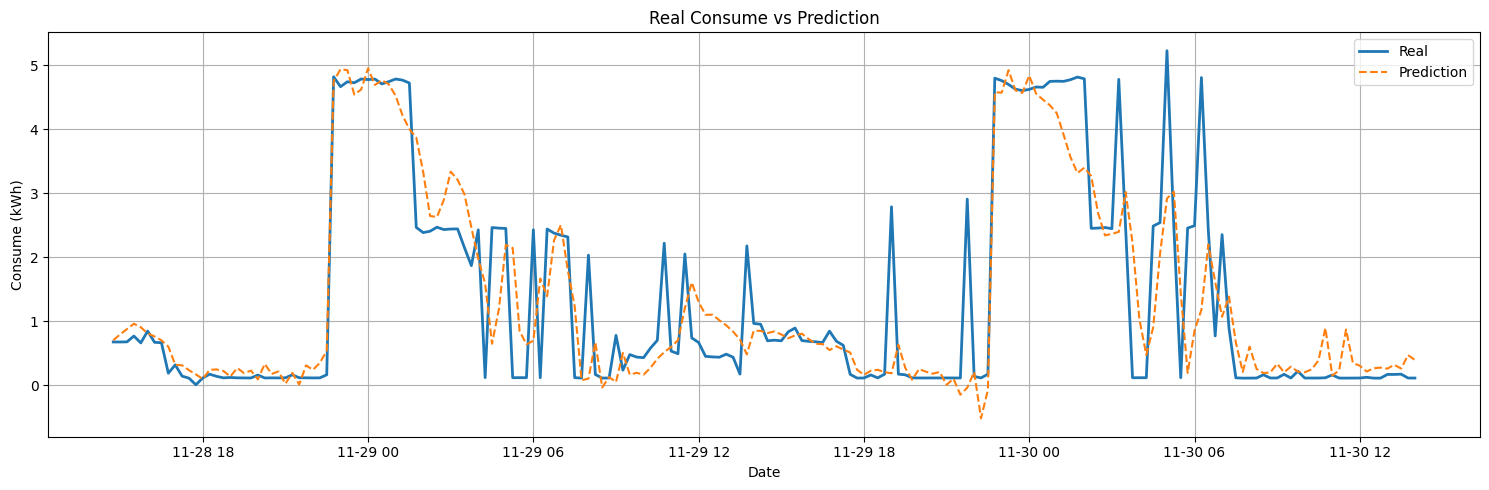

In [16]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=1, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+300:end+94+300], y_real[start+300:end+94+300], label='Real', linewidth=2)
    plt.plot(ts.index[start+300:end+94+300], y_pred[start+300:end+94+300], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=0, n_dias=1, idx=1780)

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step


C:\Users\andy0\AppData\Local\Temp\ipykernel_44828\2934949024.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False


Anomalías fuertes detectadas: 39


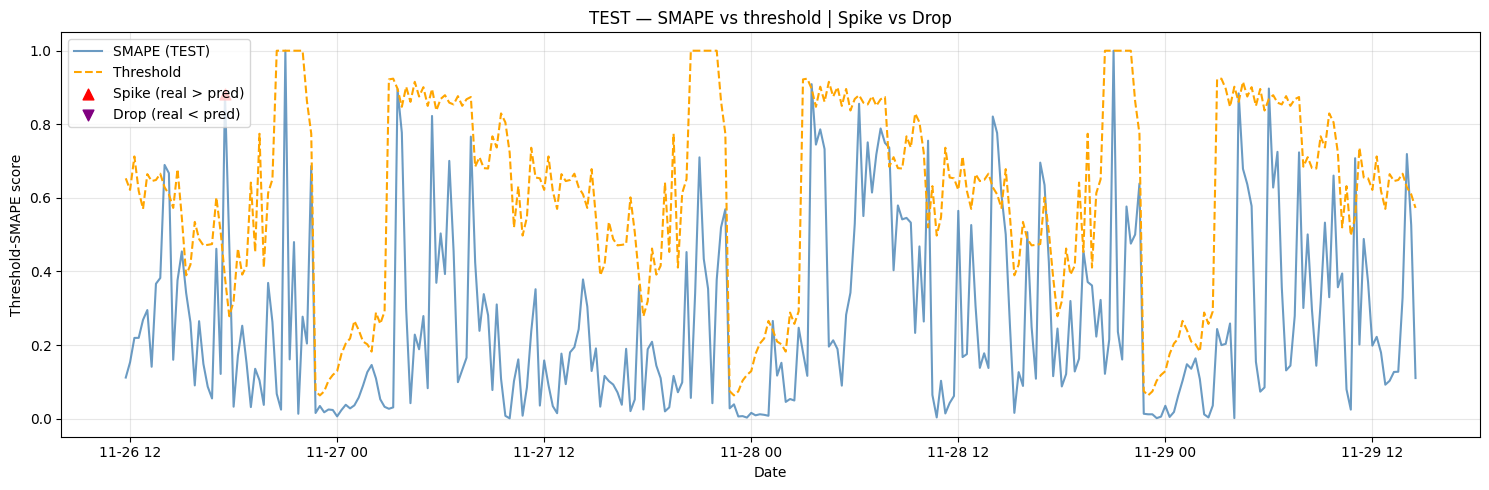

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Predicción en escala normalizada
y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred_scaled_vl = model_BiLSTM.predict([X_val_temporal, X_val_stat])

# Desescalar
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred = np.clip(y_pred, a_min=0, a_max=None)
y_real = scaler.inverse_transform(y_ts.reshape(-1, 1)).ravel()

y_pred_vl = scaler.inverse_transform(y_pred_scaled_vl.reshape(-1, 1)).ravel()
y_pred_vl = np.clip(y_pred_vl, a_min=0, a_max=None)
y_real_vl = scaler.inverse_transform(y_vl.reshape(-1, 1)).ravel()

# ── VAL ──────────────────────────────────────────────────────────────────────
df_vl = pd.DataFrame({
    'y_real': y_real_vl,
    'y_pred': y_pred_vl,
}, index=val[96:-1].index)

df_vl['quarter'] = df_vl.index.hour * 4 + df_vl.index.minute // 15
df_vl['error_kwh'] = np.abs(df_vl['y_real'] - df_vl['y_pred'])
df_vl['score_rel'] = df_vl['error_kwh'] / np.clip(df_vl['y_real'] + df_vl['y_pred'], a_min=1e-3, a_max=None)

P = 95
tau_by_context = df_vl.groupby('quarter')['score_rel'].quantile(P / 100)
df_vl['tau'] = df_vl['quarter'].map(tau_by_context)

# ── TEST ─────────────────────────────────────────────────────────────────────
df_test = pd.DataFrame({
    'y_real': y_real,
    'y_pred': y_pred,
}, index=test[96:-1].index)

df_test['quarter'] = df_test.index.hour * 4 + df_test.index.minute // 15
df_test['error_kwh'] = np.abs(df_test['y_real'] - df_test['y_pred'])
df_test['score_rel'] = df_test['error_kwh'] / np.clip(df_test['y_real'] + df_test['y_pred'], a_min=1e-3, a_max=None)
df_test['tau'] = df_test['quarter'].map(tau_by_context)

df_test['anomaly_strong'] = df_test['score_rel'] > (df_test['tau'] + 0.3)
df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False
df_test['anomaly'] = df_test['score_rel'] > (df_test['tau'] + 0.1)

if df_test['anomaly_strong'].sum() > 0:
    print(f"Anomalías fuertes detectadas: {df_test['anomaly_strong'].sum()}")

# ── Anomaly type (solo sobre anomaly_strong) ──────────────────────────────────
df_test['anomaly_type_pred'] = 'none'
mask = df_test['anomaly_strong']
df_test.loc[mask & (df_test['y_real'] > df_test['y_pred']), 'anomaly_type_pred'] = 'spike'
df_test.loc[mask & (df_test['y_real'] < df_test['y_pred']), 'anomaly_type_pred'] = 'drop'

# ── Anomalías persistentes ────────────────────────────────────────────────────
def mark_persistent(anomaly_series, min_gap=2, max_gap=4):
    result = pd.Series(False, index=anomaly_series.index)
    positions = [i for i, v in enumerate(anomaly_series) if v]

    for i in range(len(positions) - 1):
        t1 = positions[i]
        t2 = positions[i + 1]
        gap = t2 - t1
        if min_gap <= gap <= max_gap:
            result.iloc[t1:t2 + 1] = True

    min_length = 3
    in_group = False
    group_start = 0

    for i in range(len(result)):
        if result.iloc[i] and not in_group:
            in_group = True
            group_start = i
        elif not result.iloc[i] and in_group:
            in_group = False
            if i - group_start < min_length:
                result.iloc[group_start:i] = False

    if in_group and len(result) - group_start < min_length:
        result.iloc[group_start:] = False

    return result

df_test['anomaly_persistent'] = mark_persistent(df_test['anomaly'], min_gap=3, max_gap=4)
df_test['anomaly_final'] = df_test['anomaly_strong'] | df_test['anomaly_persistent']

# ── Plot ──────────────────────────────────────────────────────────────────────
start = 0
end   = 300

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    df_test.index[start:end],
    df_test['score_rel'].iloc[start:end],
    label='SMAPE (TEST)', color='steelblue', alpha=0.8
)
ax.plot(
    df_test.index[start:end],
    df_test['tau'].iloc[start:end],
    '--', label='Threshold', color='orange'
)

spikes = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'spike']
ax.scatter(spikes.index, spikes['score_rel'],
           color='red', marker='^', s=60, label='Spike (real > pred)', zorder=5)

drops = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'drop']
ax.scatter(drops.index, drops['score_rel'],
           color='purple', marker='v', s=60, label='Drop (real < pred)', zorder=5)

ax.set_title('TEST — SMAPE vs threshold | Spike vs Drop')
ax.set_xlabel('Date')
ax.set_ylabel('Threshold-SMAPE score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.show()

In [18]:
df_test['is_anomaly'] = df.loc[df_test.index, 'is_anomaly']
df_test['anomaly_type'] = anomaly.loc[df_test.index]
y_true = df_test['is_anomaly'].astype(int)
y_pred = df_test['anomaly_final'].astype(int)

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[3342   56]
 [   7    3]]


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3398
           1       0.05      0.30      0.09        10

    accuracy                           0.98      3408
   macro avg       0.52      0.64      0.54      3408
weighted avg       1.00      0.98      0.99      3408



In [21]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop', 'level_shift']:

    y_true = (df_test['anomaly_type']      == t).astype(int)  # etiquetas reales
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)  # etiquetas predichas

    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true, y_pred))


Tipo: spike
[[3385   18]
 [   4    1]]

Tipo: drop
[[3385   18]
 [   3    2]]

Tipo: level_shift
[[3408]]


c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [22]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop','level_shift']:
    
    y_true_type = (df_test['anomaly_type'] == t).astype(int)
    y_pred = df_test['anomaly_persistent'].astype(int)
    
    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true_type, y_pred))


Tipo: spike
[[3381   22]
 [   5    0]]

Tipo: drop
[[3381   22]
 [   5    0]]

Tipo: level_shift
[[3386   22]
 [   0    0]]



  TIPO: spike

✅ Verdadero Positivo (TP) — índice posicional 3219 (1 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_44828\3231948400.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


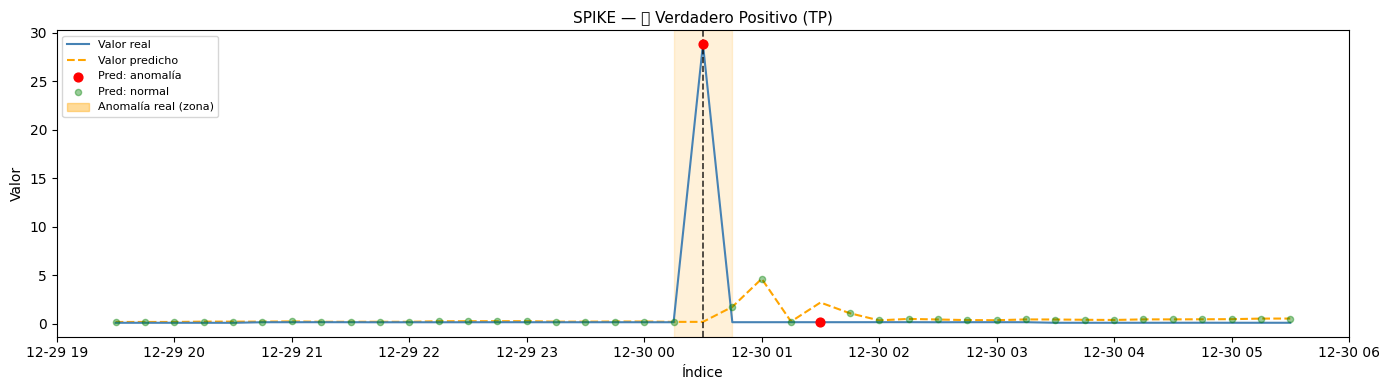

C:\Users\andy0\AppData\Local\Temp\ipykernel_44828\3231948400.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



❌ Falso Positivo (FP) — índice posicional 1373 (18 casos totales)


c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


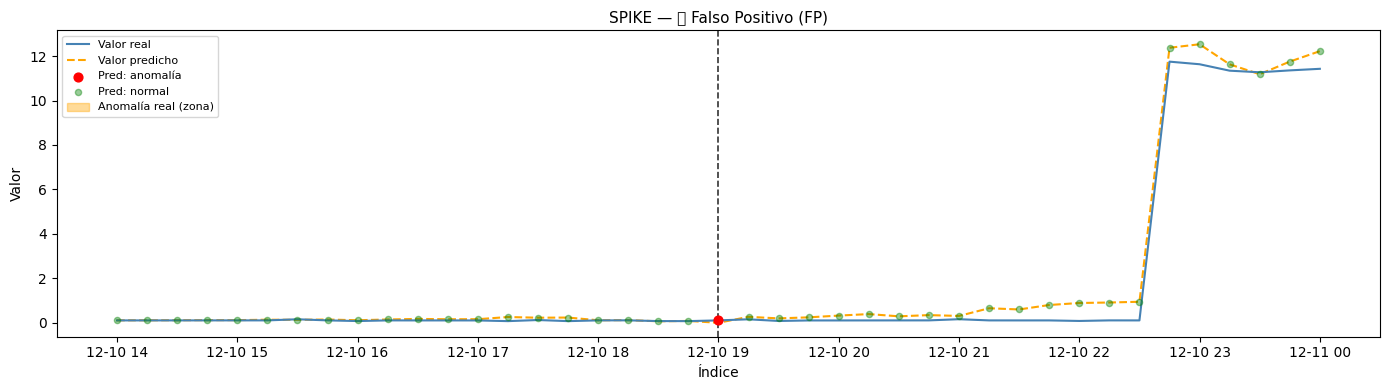


⚠️  Falso Negativo (FN) — índice posicional 2076 (4 casos totales)


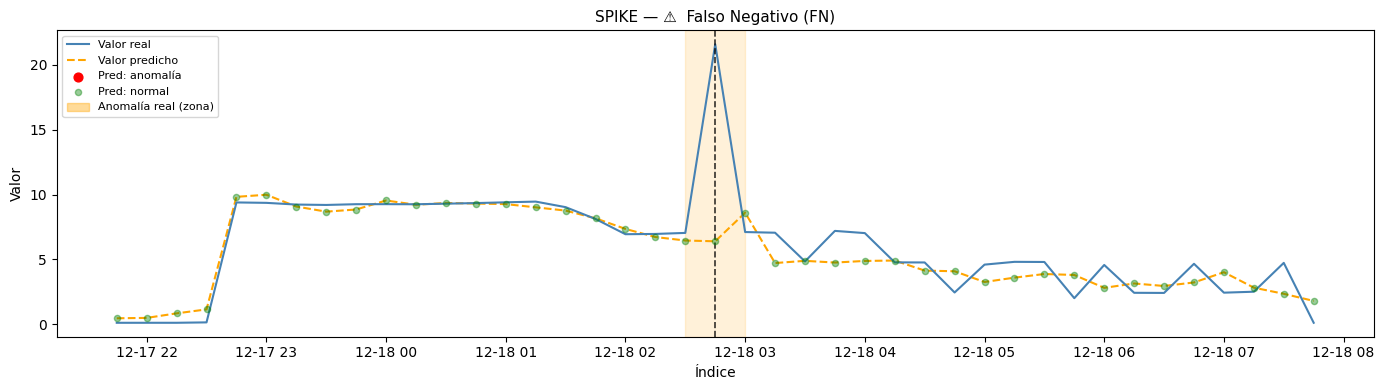


  TIPO: drop

✅ Verdadero Positivo (TP) — índice posicional 1073 (2 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_44828\3231948400.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


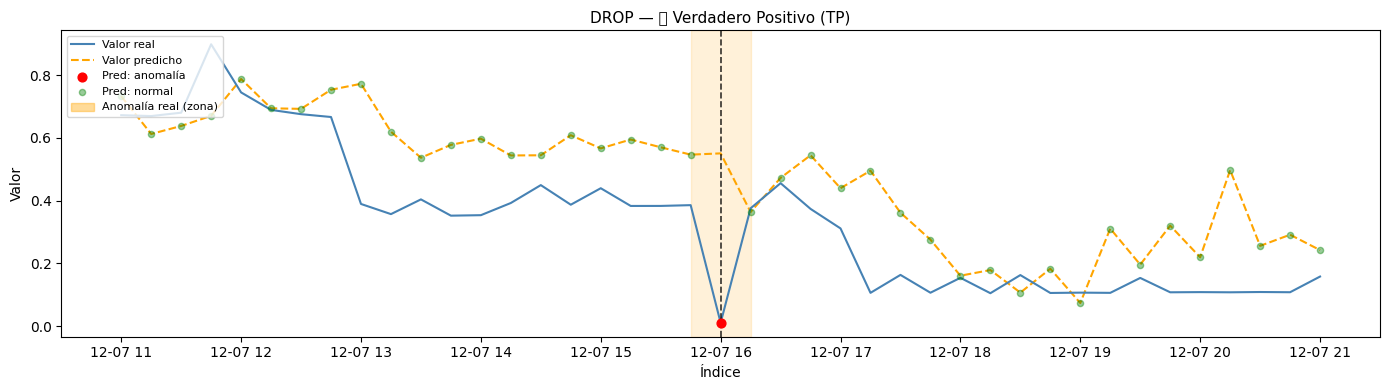


❌ Falso Positivo (FP) — índice posicional 2732 (18 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_44828\3231948400.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


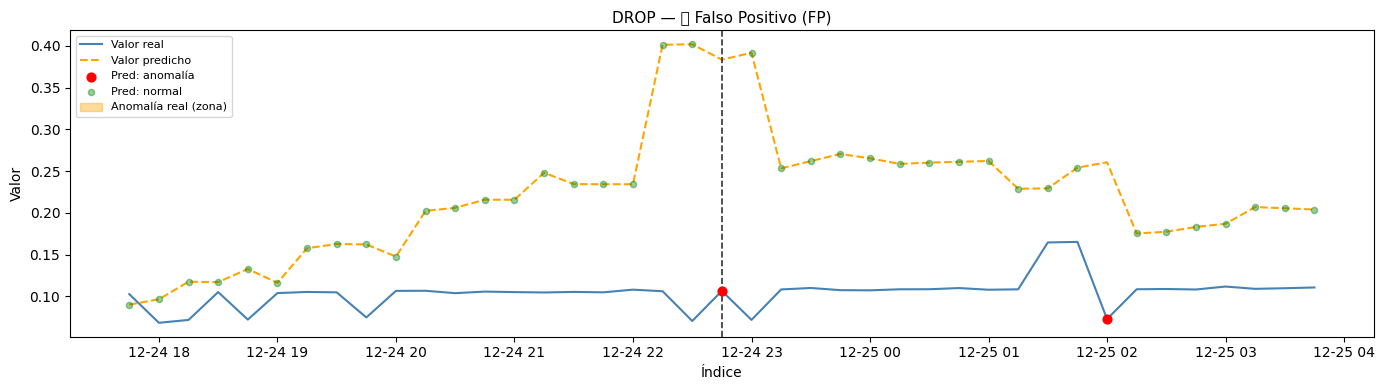


⚠️  Falso Negativo (FN) — índice posicional 2326 (3 casos totales)


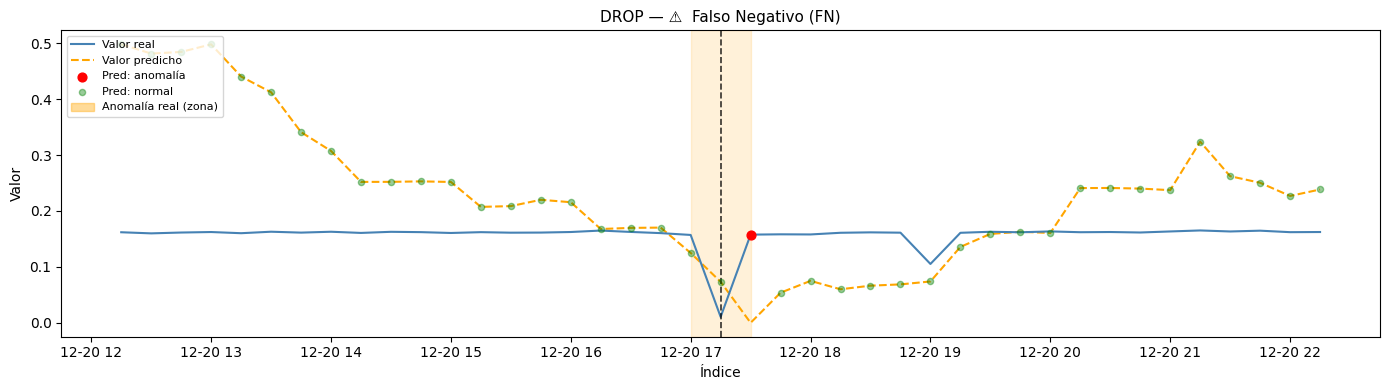


  TIPO: level_shift

✅ Verdadero Positivo (TP): Sin ejemplos

❌ Falso Positivo (FP): Sin ejemplos

⚠️  Falso Negativo (FN): Sin ejemplos


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

case_types = ['spike', 'drop', 'level_shift']

def plot_caso(df, idx, titulo="", ventana=20):
    start = max(0, idx - ventana)
    end   = min(len(df), idx + ventana + 1)
    subset = df.iloc[start:end]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    ax.plot(subset.index, subset['y_real'], color='steelblue', linewidth=1.5, label='Valor real', zorder=3)
    ax.plot(subset.index, subset['y_pred'], color='orange', linestyle='--', label='Valor predicho', zorder=2)
    
    pred_pos = subset[subset['anomaly_strong'] == 1]
    pred_neg = subset[subset['anomaly_strong'] == 0]
    ax.scatter(pred_pos.index, pred_pos['y_real'], color='red',   s=40, zorder=5, label='Pred: anomalía')
    ax.scatter(pred_neg.index, pred_neg['y_pred'], color='green', s=20, zorder=5, label='Pred: normal', alpha=0.4)
    
    if hasattr(subset.index, 'freq') and subset.index.freq is not None:
        half_step = pd.tseries.frequencies.to_offset(subset.index.freq)
    else:
        diffs = pd.Series(subset.index).diff().dropna()
        half_step = diffs.median() / 2

    # Sombrea con anomaly_type (etiquetas REALES)
    for i in subset.index:
        if subset.loc[i, 'anomaly_type'] != 'none':
            ax.axvspan(i - half_step, i + half_step, alpha=0.15, color='orange', zorder=1)
    
    punto_x = df.index[idx]
    ax.axvline(x=punto_x, color='black', linestyle='--', linewidth=1.2, alpha=0.8, zorder=4)
    
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Índice")
    ax.set_ylabel("Valor")
    
    naranja = mpatches.Patch(color='orange', alpha=0.4, label='Anomalía real (zona)')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [naranja], labels=labels + ['Anomalía real (zona)'], fontsize=8, loc='upper left')
    
    plt.tight_layout()
    plt.show()


for t in case_types:
    print(f"\n{'='*55}")
    print(f"  TIPO: {t}")
    print(f"{'='*55}")
    
    # anomaly_type      → etiquetas reales (a mano)
    # anomaly_type_pred → etiquetas predichas (modelo)
    y_true = (df_test['anomaly_type']      == t).astype(int)
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)
    
    masks = {
        '✅ Verdadero Positivo (TP)': (y_true == 1) & (y_pred == 1),
        '❌ Falso Positivo (FP)'    : (y_true == 0) & (y_pred == 1),
        '⚠️  Falso Negativo (FN)'   : (y_true == 1) & (y_pred == 0),
    }
    
    for label, mask in masks.items():
        indices_pos = np.where(mask)[0]
        
        if len(indices_pos) == 0:
            print(f"\n{label}: Sin ejemplos")
            continue
        
        idx_pos = indices_pos[len(indices_pos) // 2]
        print(f"\n{label} — índice posicional {idx_pos} ({len(indices_pos)} casos totales)")
        plot_caso(df_test, idx=idx_pos, titulo=f"{t.upper()} — {label}", ventana=20)

In [24]:
model_BiLSTM.save("model_BiLSTM_officeD.keras")